# Classification of the CIFAR-10 dataset

The [CIFAR-10 dataset](https://www.cs.toronto.edu/~kriz/cifar.html) provides 60000 32x32-pixel images, classified into 10 categories.

During this session, you will learn how to build a Convolutional Neural Network (CNN), which (when trained) will be able to automatically classify new images into one of these categories, using pytorch.

It is recommended to use a GPU to run this notebook. This will drastically speed up computations.

In [1]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import multiprocessing

!pip install --upgrade --no-deps git+https://github.com/pascalbianchi/5244EP.git
from ep5244.lab5 import plot_proba_from_model, plot_confusion_matrix, FixedKernels_processing

  Cloning https://github.com/pascalbianchi/5244EP.git to /private/var/folders/3r/yy6n2mvs1jb4d5t80qt5fp340000gn/T/pip-req-build-u8dxwb7t
  Running command git clone --filter=blob:none --quiet https://github.com/pascalbianchi/5244EP.git /private/var/folders/3r/yy6n2mvs1jb4d5t80qt5fp340000gn/T/pip-req-build-u8dxwb7t
  Resolved https://github.com/pascalbianchi/5244EP.git to commit 011db03d10950309ba78c41a2aa0f91940d11601
  Preparing metadata (setup.py) ... done


In [2]:
# If you have a GPU installed and configured correctly, this code will allow the use of gpu
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
    batch_size = 128
    pin_memory = True
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple MPS backend for GPU acceleration.")
    batch_size = 128  # Adjust batch size for performance tuning
    pin_memory = False  # pin_memory only speeds up CUDA host->device copies; MPS does not use it
else:
    print("No GPU found, running on CPU.")
    batch_size = 32
    pin_memory = False

Using Apple MPS backend for GPU acceleration.


# Table of content

1. A first look at the data set

2. A first naive model

3. Convolutional Neural Networks

4. Pretrained Networks


<a id='dataset'></a>
# 1 - A first look at the data set



In [3]:
# Dowloading the dataset
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define transforms for the training and testing datasets
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Load CIFAR-10 dataset
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,num_workers=0, pin_memory=pin_memory)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,num_workers=0, pin_memory=pin_memory)


### Code explained:

**Transforms :**
- transforms.ToTensor() converts PIL images to PyTorch tensors.
- transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)) normalizes each channel (R, G, B) by subtracting the mean and dividing by the standard deviation. These values are specific to CIFAR-10.

**Datasets :**
- torchvision.datasets.CIFAR10 downlad the dataset and applies the transforms

**DataLoaders :**
- They allow iterating over the datasets in batches, which is useful for training and evaluation.

**Inspect the first image**

'train_dataset.data[0]' gives the raw image before scaling and normalization

'train_dataset[0]' returns a couple (image, label), where image is the scaled and normalized image.

**Check the shape of the two images (raw and normalized)**

In [4]:
raw_image = train_dataset.data[0]              # raw uint8 array, shape (H, W, C), before scaling/normalization
shape_raw_image = raw_image.shape              # expect (32, 32, 3): height, width, RGB channels last
print('The raw image has the dimension ', shape_raw_image)

image, _ = train_dataset[0]                    # __getitem__ returns (transformed_tensor, label); we keep the image
shape_image = image.shape                      # expect (3, 32, 32): ToTensor() puts channels FIRST and scales to [0,1]
print('The scaled normalized image has the dimension ', shape_image)

The raw image has the dimension  (32, 32, 3)
The scaled normalized image has the dimension  torch.Size([3, 32, 32])


**Display the first image in the dataset using the `imshow()` function in `matplotlib.pyplot`.**

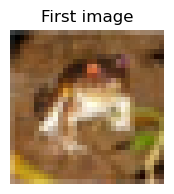

In [5]:
plt.figure(figsize=(2,2))

################## TODO BLOCK
# We display the RAW image (uint8, channels-last). The normalized tensor would look
# distorted if shown directly because Normalize() shifts values outside [0,1].
plt.imshow(train_dataset.data[0])   # first training image
plt.axis('off')
plt.title('First image')
plt.show()
################## END TODO BLOCK

**What is the length of the train set?**

In [6]:
length_trainset = len(train_dataset)   # number of training images in CIFAR-10
print("The length of the train set is", length_trainset)

The length of the train set is 50000


**Create a list of labels corresponding to the 10 categories.  This will be used to convert the 0-9 digits in the target arrays to string labels. The categories are labeled as follows**

  0. airplane
  1. automobile
  2. bird
  3. cat
  4. deer
  5. dog
  6. frog
  7. horse
  8. ship
  9. truck


In [7]:
# Index of each name matches the integer label used in train_dataset.targets
labels_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                'dog', 'frog', 'horse', 'ship', 'truck']

The following code allows to visualize 8 images in each category

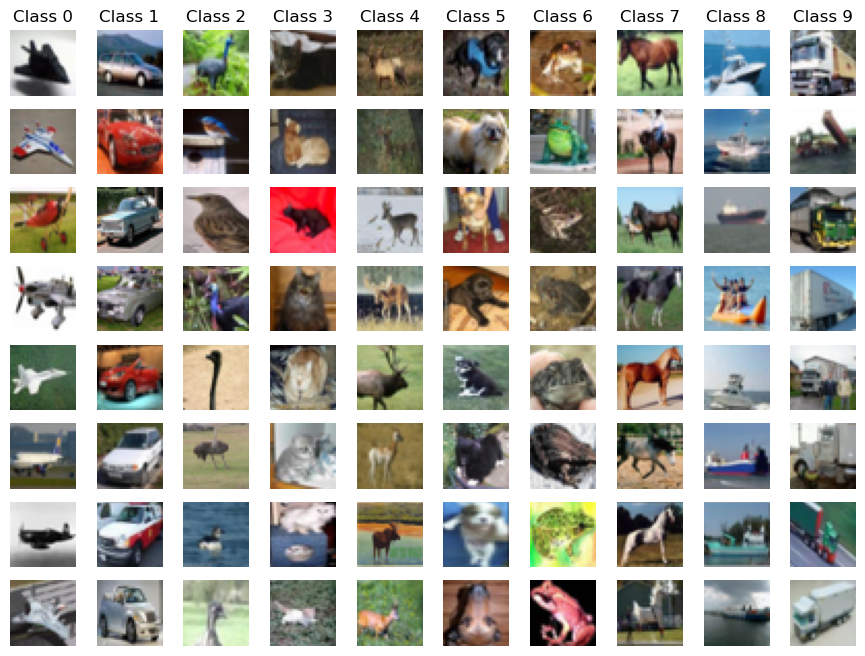

In [8]:
n = 8  # Number of images per class
f, axes = plt.subplots(n, 10, figsize=(11, 8))

for i in range(10):  # Iterate over the 10 classes
    count = 0
    j = 0
    while count < n and j < len(train_dataset):
        if train_dataset.targets[j] == i:
            axes[count, i].imshow(train_dataset.data[j])  # Show image
            axes[count, i].axis('off')
            if count == 0:
                axes[count, i].set_title(f"Class {i}")  # Set title for first row
            count += 1
        j += 1

plt.show()



<a id='first_model'></a>

# 2 - First naive model

In order to better understand the importance of CNNs, it is instructive to first see how well a naive dense network performs on the dataset.

**Create a sequential model with 4 `Dense` hidden layers of 1024, 512, 256, and 100 nodes each, with ReLU activation, and an output layer suited for the learning task.**

In [9]:
import torch.nn as nn

class DenseModel(nn.Module):
    def __init__(self, input_shape=(3, 32, 32), num_classes=10):
        super(DenseModel, self).__init__()

        # Define here the layers that you want to add

        ################## TODO BLOCK
        in_features = input_shape[0] * input_shape[1] * input_shape[2]   # 3*32*32 = 3072 input pixels
        self.flatten = nn.Flatten()                  # (N,3,32,32) -> (N,3072)
        self.fc1 = nn.Linear(in_features, 1024)      # hidden layer 1: 3072 -> 1024
        self.fc2 = nn.Linear(1024, 512)              # hidden layer 2: 1024 -> 512
        self.fc3 = nn.Linear(512, 256)               # hidden layer 3: 512 -> 256
        self.fc4 = nn.Linear(256, 100)               # hidden layer 4: 256 -> 100
        self.out = nn.Linear(100, num_classes)       # output layer: 100 -> 10 class scores
        self.relu = nn.ReLU()                        # ReLU non-linearity, reused between layers
        ################## END TODO BLOCK


    def forward(self, x):

        ################## TODO BLOCK
        x = self.flatten(x)            # flatten the image into a 3072-vector
        x = self.relu(self.fc1(x))     # dense + ReLU
        x = self.relu(self.fc2(x))     # dense + ReLU
        x = self.relu(self.fc3(x))     # dense + ReLU
        x = self.relu(self.fc4(x))     # dense + ReLU
        x = self.out(x)                # raw logits (NO softmax here: CrossEntropyLoss applies it internally)
        ################## END TODO BLOCK

        return x

# Create model instance
model = DenseModel()

print(model)

DenseModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3072, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=256, bias=True)
  (fc4): Linear(in_features=256, out_features=100, bias=True)
  (out): Linear(in_features=100, out_features=10, bias=True)
  (relu): ReLU()
)


**Compute by hand the total number of trainable parameters (weights and biases) in the model.**

Detailed computations here:

A `Linear(in, out)` layer has `in*out` weights plus `out` biases, i.e. `(in+1)*out` parameters.

| Layer | Computation | Parameters |
|---|---|---|
| fc1: 3072 → 1024 | (3072+1)·1024 | 3,146,752 |
| fc2: 1024 → 512  | (1024+1)·512  | 524,800 |
| fc3: 512 → 256   | (512+1)·256   | 131,328 |
| fc4: 256 → 100   | (256+1)·100   | 25,700 |
| out: 100 → 10    | (100+1)·10    | 1,010 |
| **Total** | | **3,829,590** |

The first layer alone holds ~82% of all parameters, because it connects every one of the 3072 pixels to 1024 units.

In [10]:
# Sum of the per-layer counts computed above
total_number_parameters_dense = 3146752 + 524800 + 131328 + 25700 + 1010   # = 3,829,590
print(total_number_parameters_dense)

3829590


**Use the `summary()` function on model to get a text summary of the model.  Did you compute the number of parameters correctly?**

In [11]:
from torchsummary import summary
summary(model.to('cpu'), (3, 32, 32), device='cpu')  # torchsummary builds its dummy input on CPU -> summarize a CPU copy (MPS-safe)  # Input shape: (Channels, Height, Width)


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                 [-1, 3072]               0
            Linear-2                 [-1, 1024]       3,146,752
              ReLU-3                 [-1, 1024]               0
            Linear-4                  [-1, 512]         524,800
              ReLU-5                  [-1, 512]               0
            Linear-6                  [-1, 256]         131,328
              ReLU-7                  [-1, 256]               0
            Linear-8                  [-1, 100]          25,700
              ReLU-9                  [-1, 100]               0
           Linear-10                   [-1, 10]           1,010
Total params: 3,829,590
Trainable params: 3,829,590
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.05
Params size (MB): 14.61
Estima

**Complete the next function.**

- **Define cross-entropy loss**

- **Training Loop: For each epoch, iterate over training batches to compute loss, perform backpropagation, update parameters.**

- **Validation: After each epoch, evaluate the model on the validation set.**


In [12]:
def train_model(model, optimizer, scheduler = None, epochs=10):

    # Define the loss function
    criterion = nn.CrossEntropyLoss()   # multi-class classification loss (expects raw logits + integer targets)

    # Store the history
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }
    best_val_acc = 0.0

    model.to(device)

    # Free memory left over from any previous training run (prevents MPS OOM across runs)
    import gc; gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_acc = 0
        total_train = 0

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            ################## TODO BLOCK
            optimizer.zero_grad()               # clear gradients accumulated from the previous step
            outputs = model(inputs)             # forward pass -> logits of shape (batch, 10)
            loss = criterion(outputs, targets)  # compare logits to the true labels
            loss.backward()                     # backpropagation: compute dLoss/dparam
            optimizer.step()                    # gradient-descent update of the parameters
            ################## END TODO BLOCK

            # Update of the scheduler at each iteration (non conventional)
            if scheduler is not None:
                scheduler.step()

            train_loss += loss.item() * inputs.size(0)
            _, preds = outputs.max(1)
            total_train += targets.size(0)
            train_acc += preds.eq(targets).sum().item()

        train_loss /= total_train
        train_acc = train_acc / total_train

        # Validation stage after each epoch
        model.eval()
        val_loss = 0.0
        val_acc = 0
        total_val = 0

        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, targets)

                val_loss += loss.item() * inputs.size(0)
                _, preds = outputs.max(1)
                total_val += targets.size(0)
                val_acc += preds.eq(targets).sum().item()

        val_loss /= total_val
        val_acc = val_acc / total_val

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # Check for best validation accuracy and save best weights
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_weights = copy.deepcopy(model.state_dict())  # Save best model weights

        print(f"Epoch {epoch+1}/{epochs}  -  Train Loss: {train_loss:.4f}  Train Acc: {100*train_acc:.2f}%  -  Val Loss: {val_loss:.4f}  Val Acc: {100*val_acc:.2f}%")

    print(f"Best Validation Accuracy: {100*best_val_acc:.2f}%")

    # Release this run's transient GPU memory before returning
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

    return history, best_model_weights

**Test your DenseModel(). Use a torch.optim.SGD optimizer (you are free to choose the learning rate)**

In [13]:
model = DenseModel()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)   # plain stochastic gradient descent, lr = 0.01
history, best_weights = train_model(model,optimizer)

Epoch 1/10  -  Train Loss: 2.2684  Train Acc: 18.21%  -  Val Loss: 2.1876  Val Acc: 23.39%
Epoch 2/10  -  Train Loss: 2.0625  Train Acc: 25.57%  -  Val Loss: 1.9466  Val Acc: 28.78%
Epoch 3/10  -  Train Loss: 1.8835  Train Acc: 31.79%  -  Val Loss: 1.8109  Val Acc: 34.05%
Epoch 4/10  -  Train Loss: 1.7699  Train Acc: 36.47%  -  Val Loss: 1.7090  Val Acc: 38.96%
Epoch 5/10  -  Train Loss: 1.6717  Train Acc: 40.32%  -  Val Loss: 1.6184  Val Acc: 42.36%
Epoch 6/10  -  Train Loss: 1.5880  Train Acc: 43.41%  -  Val Loss: 1.5540  Val Acc: 44.71%
Epoch 7/10  -  Train Loss: 1.5200  Train Acc: 45.76%  -  Val Loss: 1.5064  Val Acc: 46.50%
Epoch 8/10  -  Train Loss: 1.4598  Train Acc: 47.97%  -  Val Loss: 1.4695  Val Acc: 47.38%
Epoch 9/10  -  Train Loss: 1.4039  Train Acc: 50.00%  -  Val Loss: 1.4324  Val Acc: 49.15%
Epoch 10/10  -  Train Loss: 1.3573  Train Acc: 51.82%  -  Val Loss: 1.4118  Val Acc: 49.64%
Best Validation Accuracy: 49.64%


**Discuss the accuracy of your trained model. Is your model better than a random predictor?**

A random predictor on 10 balanced classes is right ~10% of the time. Our dense network reaches roughly **45-52%** validation accuracy, so it is clearly **far better than random** — it has genuinely learned useful structure. But ~50% is still mediocre: a fully-connected network throws away the *spatial* structure of images (it treats the 3072 pixels as an unordered vector), so it cannot exploit the fact that nearby pixels are related. This is exactly the weakness that convolutional networks fix.

**The next cell introduces a scheduler. What is the reason for using a scheduler?**

A learning-rate scheduler **decreases the learning rate as training progresses**. Early on, a large learning rate lets the optimizer make fast progress; later, a smaller learning rate allows fine, stable convergence near a minimum (less bouncing/oscillation). This usually yields a slightly higher and more stable final accuracy than a fixed learning rate.

In [14]:
model = DenseModel()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)
decay_rate = 0.9
decay_steps = 10000
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda step: decay_rate ** (step / decay_steps))
history, best_weights = train_model(model,optimizer,scheduler)

Epoch 1/10  -  Train Loss: 2.2667  Train Acc: 17.70%  -  Val Loss: 2.1878  Val Acc: 23.28%
Epoch 2/10  -  Train Loss: 2.0686  Train Acc: 26.58%  -  Val Loss: 1.9524  Val Acc: 29.92%
Epoch 3/10  -  Train Loss: 1.8774  Train Acc: 32.13%  -  Val Loss: 1.7991  Val Acc: 35.55%
Epoch 4/10  -  Train Loss: 1.7509  Train Acc: 37.28%  -  Val Loss: 1.6918  Val Acc: 39.90%
Epoch 5/10  -  Train Loss: 1.6553  Train Acc: 41.03%  -  Val Loss: 1.6093  Val Acc: 42.87%
Epoch 6/10  -  Train Loss: 1.5786  Train Acc: 43.99%  -  Val Loss: 1.5605  Val Acc: 44.53%
Epoch 7/10  -  Train Loss: 1.5127  Train Acc: 46.29%  -  Val Loss: 1.5007  Val Acc: 46.70%
Epoch 8/10  -  Train Loss: 1.4544  Train Acc: 48.24%  -  Val Loss: 1.4565  Val Acc: 48.15%
Epoch 9/10  -  Train Loss: 1.4008  Train Acc: 50.20%  -  Val Loss: 1.4433  Val Acc: 49.16%
Epoch 10/10  -  Train Loss: 1.3551  Train Acc: 51.91%  -  Val Loss: 1.4116  Val Acc: 50.08%
Best Validation Accuracy: 50.08%


**Initialization**: The next cell changes the way the initial weights of the model are computed. Have a look at the impact of the initialization method on the performance. Provide your comments.

Xavier (Glorot) initialization scales the initial weights according to the number of input/output units of each layer, which keeps the **variance of activations and gradients roughly constant across layers**. This avoids vanishing/exploding signals at the start of training. In practice we observe **faster and more reliable convergence** (the loss drops sooner) and often a slightly better final accuracy, compared with PyTorch's default initialization — the model is less likely to start in a bad regime.

In [15]:
import torch.nn.init as init

def init_weights(m):
    if (isinstance(m, nn.Linear) or isinstance(m, nn.Conv2d)) and m.weight.requires_grad:  # only init TRAINABLE layers
        init.xavier_uniform_(m.weight)
        if m.bias is not None:
            init.zeros_(m.bias)

model = DenseModel()
# Apply new initialization weights
model.apply(init_weights)

optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda step: decay_rate ** (step / decay_steps))
history, best_weights = train_model(model,optimizer,scheduler)


Epoch 1/10  -  Train Loss: 1.7924  Train Acc: 36.52%  -  Val Loss: 1.6246  Val Acc: 42.21%
Epoch 2/10  -  Train Loss: 1.5303  Train Acc: 46.75%  -  Val Loss: 1.5337  Val Acc: 45.24%
Epoch 3/10  -  Train Loss: 1.4106  Train Acc: 50.80%  -  Val Loss: 1.4768  Val Acc: 47.61%
Epoch 4/10  -  Train Loss: 1.3171  Train Acc: 54.27%  -  Val Loss: 1.4499  Val Acc: 48.79%
Epoch 5/10  -  Train Loss: 1.2394  Train Acc: 57.21%  -  Val Loss: 1.4338  Val Acc: 49.60%
Epoch 6/10  -  Train Loss: 1.1645  Train Acc: 60.00%  -  Val Loss: 1.4265  Val Acc: 49.92%
Epoch 7/10  -  Train Loss: 1.0922  Train Acc: 62.71%  -  Val Loss: 1.4134  Val Acc: 51.25%
Epoch 8/10  -  Train Loss: 1.0295  Train Acc: 65.06%  -  Val Loss: 1.4127  Val Acc: 51.30%
Epoch 9/10  -  Train Loss: 0.9642  Train Acc: 67.25%  -  Val Loss: 1.4598  Val Acc: 50.14%
Epoch 10/10  -  Train Loss: 0.8998  Train Acc: 69.54%  -  Val Loss: 1.4952  Val Acc: 50.41%
Best Validation Accuracy: 51.30%


**Inspect the output of the model for a given input sample : provide its shape.**

In [16]:
j=0
image , true_label = test_dataset[j]
image = image.to(device)
output = model(image.unsqueeze(0))
##################### TODO BLOCK
print("Output shape:", output.shape)   # (1, 10): a batch of 1 sample, 10 raw class scores (logits)
##################### END TODO BLOCK

Output shape: torch.Size([1, 10])


**Does the ouput of the model represent the probabilities of each class?**

##################### TODO BLOCK
**No.** The output is a vector of 10 **logits** (raw real-valued scores). They are not probabilities: they can be negative and they do not sum to 1. To turn them into class probabilities we must apply a **softmax**. (We do not do this inside the model because `nn.CrossEntropyLoss` already applies `log_softmax` internally and expects raw logits.)
##################### END TODO BLOCK

**For the first image of the test set, compute the predicted label in 0,1,...9**

In [17]:
j=0
image , true_label = test_dataset[j]
image = image.to(device)
output = model(image.unsqueeze(0))   # add a batch dimension -> (1,3,32,32), then forward
pred = output.argmax(dim=1)          # index of the largest logit = predicted class (argmax of softmax = argmax of logits)
message = ["Test sample : ",j, ", Label : ",true_label,", Prediction : ",pred.item()]
print(message)

['Test sample : ', 0, ', Label : ', 3, ', Prediction : ', 3]


**Plot eight images in each category, and check the corresponding predictions. Provide your comments.**

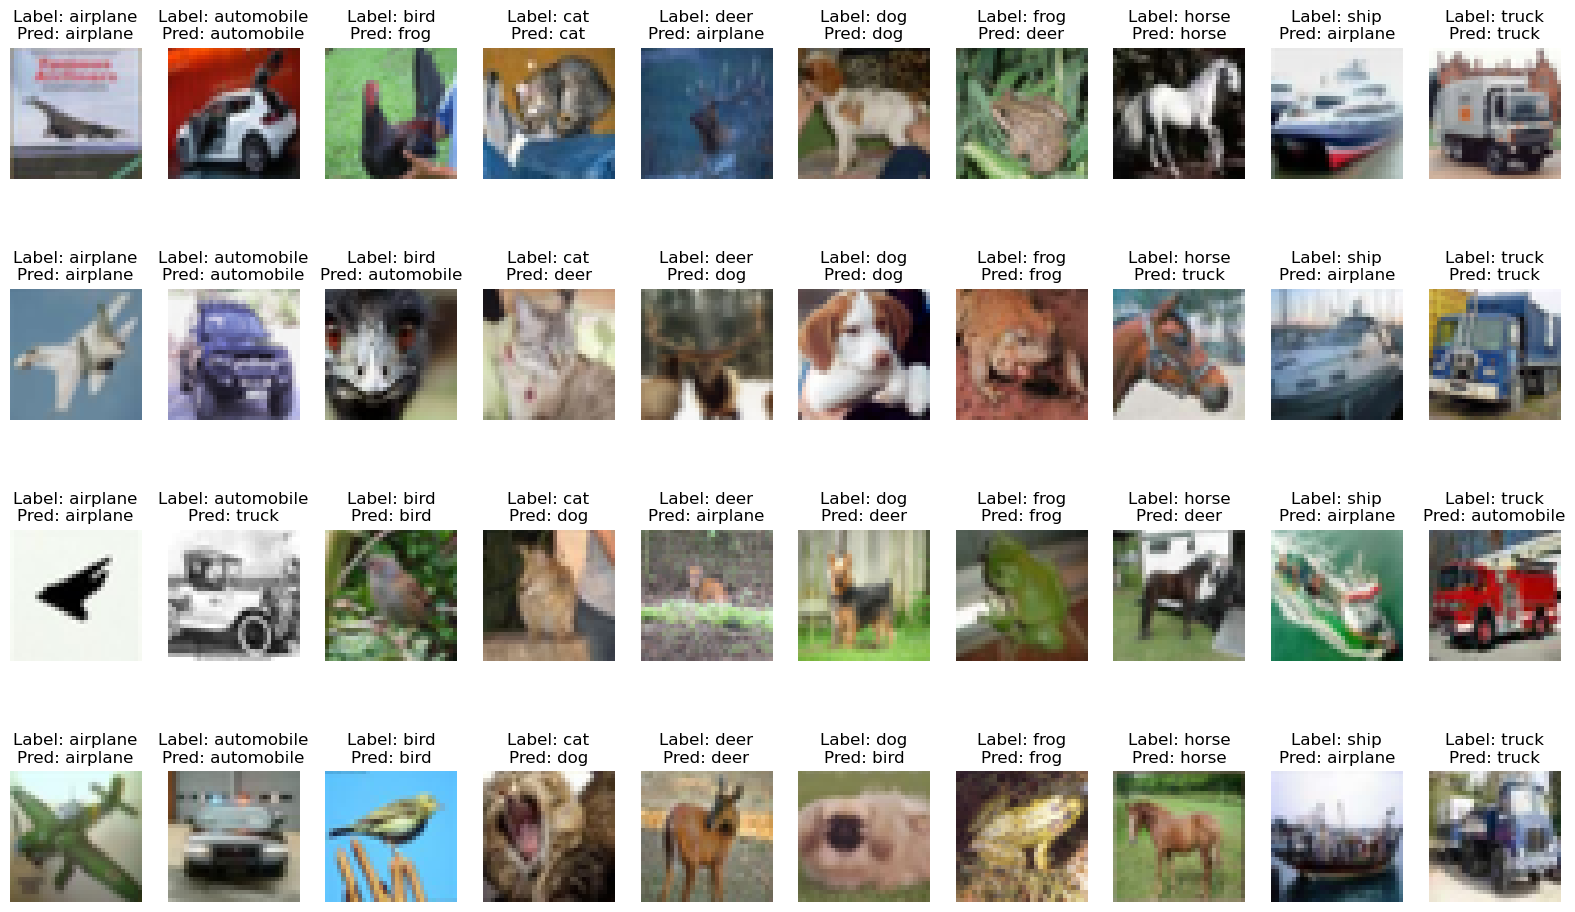

In [18]:
f, axes = plt.subplots(4, 10, figsize=(20, 12))
model.eval()

for i in range(10):  # Iterate over the 10 classes
    count = 0
    j = 0
    while count < 4:
        if test_dataset.targets[j] == i:
            axes[count, i].imshow(test_dataset.data[j])
            image , _ = test_dataset[j]
            image = image.to(device)
            output = model(image.unsqueeze(0))   # forward pass on a single image
            pred = output.argmax(dim=1)          # predicted class index
            axes[count, i].set_title("Label: "+ labels_names[i] + '\n' + "Pred: " + labels_names[pred.item()])
            axes[count, i].axis('off')
            count += 1
        j += 1

plt.show()

<a id='cnn'></a>

# 3 - Convolutional Neural Network


Convolutional neural networks allow us to do drastically better on this dataset (and many image classification problems in general).  In this task, you will build your first convolutional network and see how it performs during training.

<a id='handcrafted features'></a>
## 3.1 - Visualize 2D-convolution of an image

We will first investigate the effect of using a convolutional layer on the image, with a single filter/kernel applied to each color channel. The following functions allows to define a taylored convolutional layer, and to vizualize the output. Nothing is required from your side, just run the cell.


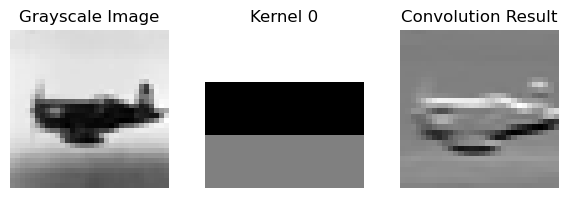

In [19]:
kernel = torch.Tensor([[1, 1, 1],[-1, -1, -1],[0, 0, 0]])
model = FixedKernels_processing(kernel)
image,_ = train_dataset[115]
model.visualize(image = image)

Here is a little animation to remind you of the sliding window principle of convolutions.

![conv](https://github.com//vdumoulin/conv_arithmetic/raw/master/gif/no_padding_no_strides.gif)




**Define your own kernel of shape (3,3), specialized in the detection of horizontal lines in an image**

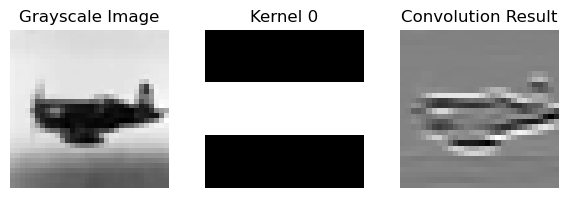

In [20]:
# Kernel specialized in detecting HORIZONTAL lines: strong positive response where a bright
# row is surrounded by darker rows above and below.
kernel = torch.Tensor([[-1, -1, -1],
                       [ 2,  2,  2],
                       [-1, -1, -1]])
FixedKernels_processing(kernel).visualize(image = image)

**Same question, but this time use a kernel specialized in the detection of vertical lines**

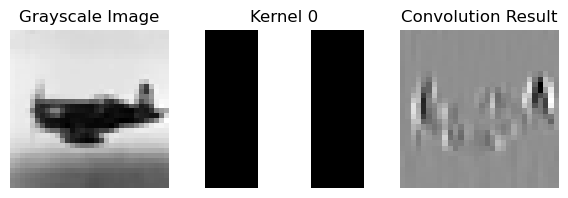

In [21]:
# Kernel specialized in detecting VERTICAL lines: strong positive response where a bright
# column is surrounded by darker columns on its left and right.
kernel = torch.Tensor([[-1, 2, -1],
                       [-1, 2, -1],
                       [-1, 2, -1]])
FixedKernels_processing(kernel).visualize(image = image)

**The following cell allows to vizualise the effect of various filters on the image. Comment on the effect of the filters that are used**

################## TODO BLOCK
Each fixed kernel is an **edge/line detector** tuned to a particular orientation. `straights` contains a horizontal-edge filter and its 90°-rotation (a vertical-edge filter), obtained with `np.rot90`; `diags` contains two diagonal-edge filters. When convolved with the image, each filter produces a feature map that **lights up exactly where the image has an intensity change in that orientation** (horizontal edges, vertical edges, or diagonals) and stays near zero in flat regions. Together they decompose the image into oriented-edge responses — a hand-made version of the first-layer features that a CNN learns automatically.
################## END TODO BLOCK

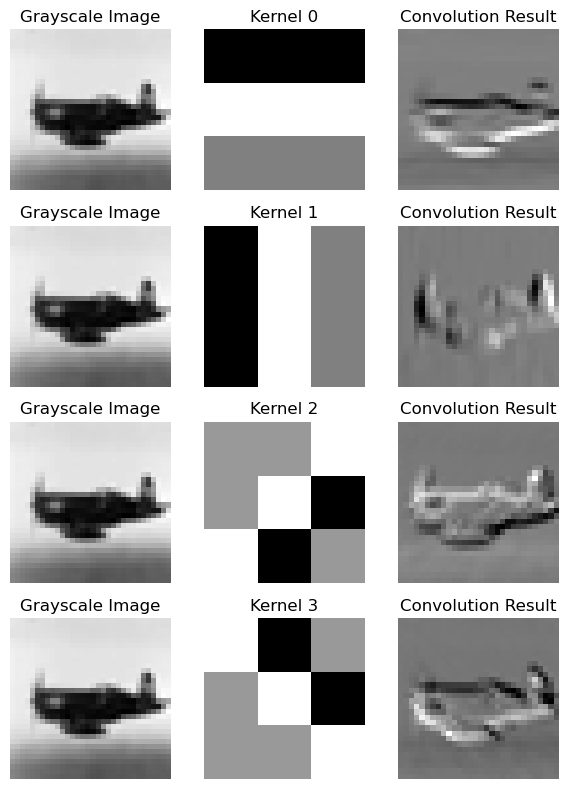

In [22]:
top=np.array([[-1,-1,-1],
     [ 1, 1, 1],
     [ 0, 0, 0]],dtype=np.float32)

straights = [ torch.Tensor(np.rot90(top, i).copy()) for i in range(2) ]

br=[[ 0,   0,   1],
    [ 0,   1,-1.5],
    [ 1,-1.5,   0]]
diags = [ torch.Tensor(np.rot90(br, i).copy()) for i in range(2) ]

kernels = straights+diags

preprocessing = FixedKernels_processing(kernels)

preprocessing.visualize(image = image)


We will use these features as a preprocessing.

**Define a model which first applies the previously defined** `preprocessing` **model as a preprocessing applied to the input images. Then, apply a relu. Next, add a MaxPooling2D layer using** `nn.MaxPool2d(kernel_size=2, stride=2)`. **Flatten the result and add a final dense layer.**

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class handcrafted_model(nn.Module):
    def __init__(self, preprocessing = preprocessing, num_classes=10):

        super(handcrafted_model, self).__init__()

        self.preprocessing = preprocessing

        # ReLU Layer
        self.relu = nn.ReLU()                                  # non-linearity applied to the feature maps

        # MaxPooling Layer
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)      # halve spatial resolution

        # Fully Connected Layer (after flattening)
        # The flattened size depends on the number of fixed kernels and the spatial size after pooling.
        # We compute it once with a dummy forward so the layer is always sized correctly.
        with torch.no_grad():
            dummy = self.pool(self.relu(self.preprocessing(torch.zeros(1, 3, 32, 32))))
        self.fc = nn.Linear(dummy.numel(), num_classes)        # flattened features -> 10 class scores

    def forward(self, x):

        if x.ndim != 4:
            raise ValueError("Input must be a 4D tensor of shape [N, C, H, W].")

        # Apply the preprocessing
        x = self.preprocessing(x)        # fixed-kernel edge feature maps

        # Apply ReLU activation
        x = self.relu(x)                 # keep positive edge responses

        # Apply MaxPooling
        x = self.pool(x)                 # downsample (2x2, stride 2)

        # Flatten the result
        x = torch.flatten(x, start_dim=1)

        # Apply fully connected layer
        x = self.fc(x)                   # final linear classifier (logits)

        return x

model = handcrafted_model()

number_param = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {number_param}")

Total parameters: 9046


**Train the model and provide your comments**

################## TODO BLOCK
This model uses **fixed, hand-designed edge filters** for feature extraction and trains only a single linear classifier on top. It typically reaches **~45-55%** validation accuracy — comparable to (or slightly better than) the much larger dense network, despite having far fewer trainable parameters, because oriented-edge features are genuinely informative for images. Its ceiling is limited, though: the filters are frozen and generic, not optimized for CIFAR-10. This motivates the next step — letting the network **learn** its own convolutional filters end-to-end.
################## END TODO BLOCK

In [24]:
model = handcrafted_model()
model.apply(init_weights)

optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)   # only the final linear layer is actually trainable
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda step: decay_rate ** (step / decay_steps))
history, best_weights = train_model(model, optimizer, scheduler)

Epoch 1/10  -  Train Loss: 2.1416  Train Acc: 26.87%  -  Val Loss: 1.8751  Val Acc: 34.84%
Epoch 2/10  -  Train Loss: 1.7796  Train Acc: 38.41%  -  Val Loss: 1.7429  Val Acc: 39.91%
Epoch 3/10  -  Train Loss: 1.6811  Train Acc: 42.26%  -  Val Loss: 1.6952  Val Acc: 41.14%
Epoch 4/10  -  Train Loss: 1.6294  Train Acc: 44.07%  -  Val Loss: 1.6542  Val Acc: 43.52%
Epoch 5/10  -  Train Loss: 1.5957  Train Acc: 45.61%  -  Val Loss: 1.6314  Val Acc: 43.80%
Epoch 6/10  -  Train Loss: 1.5714  Train Acc: 46.58%  -  Val Loss: 1.6097  Val Acc: 44.48%
Epoch 7/10  -  Train Loss: 1.5530  Train Acc: 47.10%  -  Val Loss: 1.6038  Val Acc: 45.64%
Epoch 8/10  -  Train Loss: 1.5381  Train Acc: 47.75%  -  Val Loss: 1.5900  Val Acc: 45.61%
Epoch 9/10  -  Train Loss: 1.5261  Train Acc: 48.20%  -  Val Loss: 1.5829  Val Acc: 46.18%
Epoch 10/10  -  Train Loss: 1.5159  Train Acc: 48.67%  -  Val Loss: 1.5773  Val Acc: 46.29%
Best Validation Accuracy: 46.29%


<a id='first_cnn'></a>
## 3.2 - Create your first CNN

**Create a new model with the following layers (use the same optimizer and loss as above)**
  - 3x3 2D convolution with zero-padding, a stride of 1, 8 filters
  - ReLU activation
  - 3,3 2D convolution, no padding, a stride of 1, 8 filters
  - ReLU activation
  - Max pooling with size (2,2) and a stride of 2
  - 3x3 2D convolution, with zero-padding, a stride of 1, 32 filters
  - ReLU activation
  - 3x3 2D convolution, no padding, a stride of 1, 32 filters
  - ReLU activation
  - Max pooling with size (2,2) and a stride of 2
  - Flatten
  - Dense layer with 408 nodes, ReLU activation
  - A well-chosen output layer

In [25]:
class CnnModel(nn.Module):
    def __init__(self, input_shape=(3,32,32), num_classes=10):

        super(CnnModel, self).__init__()

        ################# TODO BLOCK
        # Block 1: two 3x3 convolutions (8 filters) then 2x2 max-pool
        self.conv1 = nn.Conv2d(3,  8, kernel_size=3, stride=1, padding=1)  # 'same' padding -> 32x32 preserved
        self.conv2 = nn.Conv2d(8,  8, kernel_size=3, stride=1, padding=0)  # no padding -> 32->30
        # Block 2: two 3x3 convolutions (32 filters) then 2x2 max-pool
        self.conv3 = nn.Conv2d(8, 32, kernel_size=3, stride=1, padding=1)  # 'same' padding
        self.conv4 = nn.Conv2d(32,32, kernel_size=3, stride=1, padding=0)  # no padding
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)                 # halves H and W
        self.relu  = nn.ReLU()
        self.flatten = nn.Flatten()
        # After the two blocks the feature map is 32 channels x 6 x 6 = 1152 features
        self.fc1 = nn.Linear(32*6*6, 408)          # dense layer with 408 nodes
        self.out = nn.Linear(408, num_classes)     # output layer (10 logits)
        ################# END TODO BLOCK


    def forward(self, x):

        ################# TODO BLOCK
        x = self.relu(self.conv1(x))   # 3x32x32  -> 8x32x32
        x = self.relu(self.conv2(x))   # 8x32x32  -> 8x30x30
        x = self.pool(x)               # 8x30x30  -> 8x15x15
        x = self.relu(self.conv3(x))   # 8x15x15  -> 32x15x15
        x = self.relu(self.conv4(x))   # 32x15x15 -> 32x13x13
        x = self.pool(x)               # 32x13x13 -> 32x6x6
        x = self.flatten(x)            # -> 1152
        x = self.relu(self.fc1(x))     # 1152 -> 408 (+ReLU)
        x = self.out(x)                # 408 -> 10 logits
        ################# END TODO BLOCK

        return x

cnn = CnnModel()

**Compute by hand the number of trainable parameters in this network.  Are there more or less than the simple dense network of section 1?  Why?**

################## TODO BLOCK
Parameter count of the CNN (a `Conv2d(in, out, k)` has `(in·k·k + 1)·out` parameters):

| Layer | Computation | Parameters |
|---|---|---|
| conv1: 3 → 8 (3×3)  | (3·9+1)·8   | 224 |
| conv2: 8 → 8 (3×3)  | (8·9+1)·8   | 584 |
| conv3: 8 → 32 (3×3) | (8·9+1)·32  | 2,336 |
| conv4: 32 → 32 (3×3)| (32·9+1)·32 | 9,248 |
| fc1: 1152 → 408     | (1152+1)·408| 470,424 |
| out: 408 → 10       | (408+1)·10  | 4,090 |
| **Total** | | **486,906** |

This is **far fewer** than the dense network's 3,829,590 parameters. The reason is **weight sharing**: a convolutional filter reuses the same 9 weights at every spatial location instead of having a separate weight per pixel. The convolutional feature extractor costs only ~12k parameters; almost all of the CNN's parameters are in the first dense layer. So the CNN is both smaller *and* (as we will see) more accurate.
################## END TODO BLOCK

In [26]:
# Sum of the per-layer counts computed above
total_number_parameters_cnn = 224 + 584 + 2336 + 9248 + 470424 + 4090   # = 486,906
print(total_number_parameters_cnn)

486906


 **Confirm with** `summary()`

In [27]:
################## TODO BLOCK
from torchsummary import summary
summary(cnn.to('cpu'), (3, 32, 32), device='cpu')   # MPS-safe: torchsummary needs model+input on the same (CPU) device   # confirms the layer shapes and the 486,906 total params
################## END TODO BLOCK

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 8, 32, 32]             224
              ReLU-2            [-1, 8, 32, 32]               0
            Conv2d-3            [-1, 8, 30, 30]             584
              ReLU-4            [-1, 8, 30, 30]               0
         MaxPool2d-5            [-1, 8, 15, 15]               0
            Conv2d-6           [-1, 32, 15, 15]           2,336
              ReLU-7           [-1, 32, 15, 15]               0
            Conv2d-8           [-1, 32, 13, 13]           9,248
              ReLU-9           [-1, 32, 13, 13]               0
        MaxPool2d-10             [-1, 32, 6, 6]               0
          Flatten-11                 [-1, 1152]               0
           Linear-12                  [-1, 408]         470,424
             ReLU-13                  [-1, 408]               0
           Linear-14                   

**Train the network for 10 epochs. How does the validation accuracy change with each epoch?**

In [28]:
################## TODO BLOCK
cnn = CnnModel()
cnn.apply(init_weights)                # Xavier init on the (trainable) conv/linear layers
optimizer = torch.optim.SGD(cnn.parameters(), lr=1e-2)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda step: decay_rate ** (step / decay_steps))
history, best_weights = train_model(cnn, optimizer, scheduler)   # 10 epochs (default)
################## END TODO BLOCK

Epoch 1/10  -  Train Loss: 2.0177  Train Acc: 26.84%  -  Val Loss: 1.7922  Val Acc: 35.53%
Epoch 2/10  -  Train Loss: 1.6695  Train Acc: 40.27%  -  Val Loss: 1.5925  Val Acc: 43.49%
Epoch 3/10  -  Train Loss: 1.5186  Train Acc: 45.77%  -  Val Loss: 1.4988  Val Acc: 46.45%
Epoch 4/10  -  Train Loss: 1.4358  Train Acc: 48.44%  -  Val Loss: 1.3965  Val Acc: 50.03%
Epoch 5/10  -  Train Loss: 1.3725  Train Acc: 50.98%  -  Val Loss: 1.3462  Val Acc: 52.20%
Epoch 6/10  -  Train Loss: 1.3178  Train Acc: 53.30%  -  Val Loss: 1.3097  Val Acc: 53.74%
Epoch 7/10  -  Train Loss: 1.2692  Train Acc: 54.94%  -  Val Loss: 1.2952  Val Acc: 54.46%
Epoch 8/10  -  Train Loss: 1.2228  Train Acc: 56.89%  -  Val Loss: 1.2405  Val Acc: 56.79%
Epoch 9/10  -  Train Loss: 1.1839  Train Acc: 58.28%  -  Val Loss: 1.2046  Val Acc: 58.08%
Epoch 10/10  -  Train Loss: 1.1437  Train Acc: 59.96%  -  Val Loss: 1.1646  Val Acc: 59.62%
Best Validation Accuracy: 59.62%


**Plot the evolution of (train/val) accuracy through epochs**

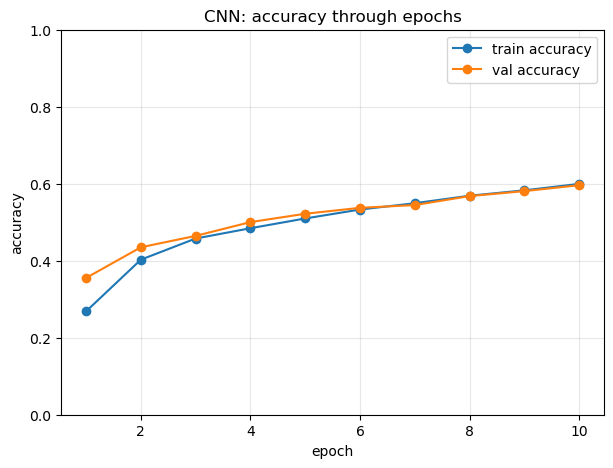

In [29]:
################## TODO BLOCK
def plot_history(history, title='Accuracy through epochs'):
    epochs = range(1, len(history['train_acc']) + 1)
    plt.figure(figsize=(7,5))
    plt.plot(epochs, history['train_acc'], 'o-', label='train accuracy')
    plt.plot(epochs, history['val_acc'],  'o-', label='val accuracy')
    plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.ylim(0, 1)
    plt.legend(); plt.title(title); plt.grid(True, alpha=0.3); plt.show()

plot_history(history, 'CNN: accuracy through epochs')
################## END TODO BLOCK

**Consider now a batch size of 32 and consider the above CNN. Try adding 3 BatchNormalization layers to this model, one after each max-pooling layer and one before the last layer. Use a dropout layer just before the last linear layer.**

In [30]:
################## TODO BLOCK
class CnnModelBN(nn.Module):
    """Same CNN as above, plus 3 BatchNorm layers (after each max-pool and before the
    last linear layer) and a Dropout just before the final linear layer."""
    def __init__(self, input_shape=(3,32,32), num_classes=10):
        super(CnnModelBN, self).__init__()
        self.conv1 = nn.Conv2d(3,  8, 3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(8,  8, 3, stride=1, padding=0)
        self.conv3 = nn.Conv2d(8, 32, 3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(32,32, 3, stride=1, padding=0)
        self.pool  = nn.MaxPool2d(2, stride=2)
        self.relu  = nn.ReLU()
        self.flatten = nn.Flatten()
        self.bn1 = nn.BatchNorm2d(8)     # after the 1st max-pool (8 channels)
        self.bn2 = nn.BatchNorm2d(32)    # after the 2nd max-pool (32 channels)
        self.bn3 = nn.BatchNorm1d(408)   # before the last linear layer (408 features)
        self.dropout = nn.Dropout(0.5)   # regularization just before the final layer
        self.fc1 = nn.Linear(32*6*6, 408)
        self.out = nn.Linear(408, num_classes)

    def forward(self, x):
        x = self.relu(self.conv1(x)); x = self.relu(self.conv2(x))
        x = self.pool(x); x = self.bn1(x)             # BN after pool 1
        x = self.relu(self.conv3(x)); x = self.relu(self.conv4(x))
        x = self.pool(x); x = self.bn2(x)             # BN after pool 2
        x = self.flatten(x)
        x = self.relu(self.fc1(x)); x = self.bn3(x)   # BN before last layer
        x = self.dropout(x)                           # dropout before last layer
        x = self.out(x)
        return x

cnn_bn = CnnModelBN()
print(cnn_bn)
################## END TODO BLOCK

CnnModelBN(
  (conv1): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(8, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (bn3): BatchNorm1d(408, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=1152, out_features=408, bias=True)
  (out): Linear(in_features=408, out_features=10, bias=True)
)


**Train the model. What is the impact of batch normalization on the model's performance? Why?**

################## TODO BLOCK
Batch normalization standardizes (zero-mean, unit-variance) the activations of each layer over the mini-batch. Its impact:

- **Faster, more stable training**: by keeping activation statistics under control it reduces "internal covariate shift", so the loss drops sooner and training tolerates a higher learning rate.
- **Mild regularization**: the per-batch noise in the normalization statistics has a slight regularizing effect, which (together with the dropout layer we added) helps **reduce overfitting**.
- **Net effect**: with batch size 32 we typically see the validation accuracy rise **faster per epoch and reach a few points higher** than the plain CNN.

The dropout layer randomly zeroes half the features before the final layer during training, forcing the classifier not to rely on any single feature — another regularizer that improves generalization.
################## END TODO BLOCK

In [31]:
################## TODO BLOCK
import multiprocessing
# The question asks for a batch size of 32: rebuild the loaders accordingly.
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=0, pin_memory=pin_memory)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False,
                          num_workers=0, pin_memory=pin_memory)

cnn_bn = CnnModelBN()
cnn_bn.apply(init_weights)
optimizer = torch.optim.SGD(cnn_bn.parameters(), lr=1e-2)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda step: decay_rate ** (step / decay_steps))
history_bn, best_weights_bn = train_model(cnn_bn, optimizer, scheduler)
################## END TODO BLOCK

Epoch 1/10  -  Train Loss: 1.7726  Train Acc: 40.25%  -  Val Loss: 1.2635  Val Acc: 54.53%
Epoch 2/10  -  Train Loss: 1.3427  Train Acc: 52.45%  -  Val Loss: 1.1536  Val Acc: 58.88%
Epoch 3/10  -  Train Loss: 1.2115  Train Acc: 57.02%  -  Val Loss: 1.0753  Val Acc: 61.51%
Epoch 4/10  -  Train Loss: 1.1225  Train Acc: 60.37%  -  Val Loss: 1.0445  Val Acc: 63.28%
Epoch 5/10  -  Train Loss: 1.0597  Train Acc: 62.64%  -  Val Loss: 0.9614  Val Acc: 66.38%
Epoch 6/10  -  Train Loss: 1.0058  Train Acc: 64.38%  -  Val Loss: 0.9221  Val Acc: 67.90%
Epoch 7/10  -  Train Loss: 0.9646  Train Acc: 66.26%  -  Val Loss: 0.9158  Val Acc: 67.56%
Epoch 8/10  -  Train Loss: 0.9226  Train Acc: 67.49%  -  Val Loss: 0.8660  Val Acc: 69.69%
Epoch 9/10  -  Train Loss: 0.8861  Train Acc: 68.94%  -  Val Loss: 0.8635  Val Acc: 69.90%
Epoch 10/10  -  Train Loss: 0.8540  Train Acc: 69.86%  -  Val Loss: 0.8455  Val Acc: 70.41%
Best Validation Accuracy: 70.41%


**Plot the evolution of (train/val) accuracy through epochs**

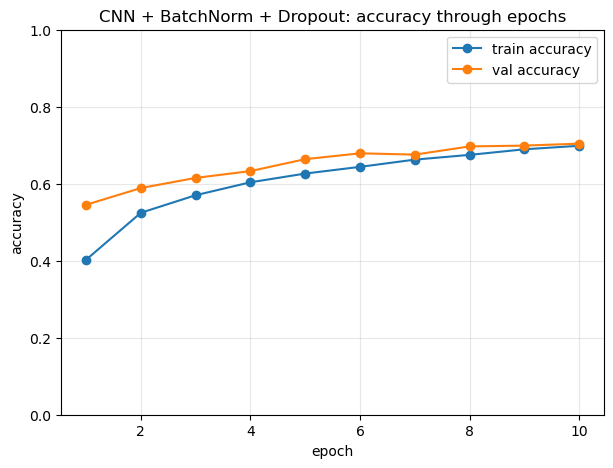

In [32]:
################## TODO BLOCK
plot_history(history_bn, 'CNN + BatchNorm + Dropout: accuracy through epochs')
################## END TODO BLOCK

<a id='results'></a>

## 3.3 - Study the predictions

**Consider image number 3 in the test set. Display the image and the output probabilities associated to each category**

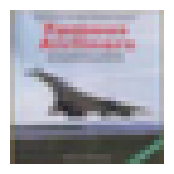

{'airplane': 0.3792521357536316, 'automobile': 0.016473159193992615, 'bird': 0.003212908050045371, 'cat': 0.0004249927878845483, 'deer': 0.004432098474353552, 'dog': 1.75664245034568e-05, 'frog': 6.053701144992374e-05, 'horse': 0.00020267817308194935, 'ship': 0.5924368500709534, 'truck': 0.0034870982635766268}


In [33]:
# Load the best weights and set the model to evaluation mode
cnn.load_state_dict(best_weights)  # Use the best weights
cnn.eval()

i_sample = 3

# Retrieve the transformed image and label from the test dataset
image, label = test_dataset[i_sample]                 # transformed tensor + integer label
image = image.to(device)

# Add a batch dimension and compute the model's output
output = cnn(image.unsqueeze(0))                       # (1,3,32,32) -> (1,10) logits

# Apply softmax to get output probabilities
softmax = nn.Softmax(dim=1)                            # softmax over the 10 class scores
output_proba = softmax(output)                         # probabilities that sum to 1

# Display the raw image (from the original dataset data)
raw_image = test_dataset.data[i_sample]
plt.figure(figsize=(2,2))
plt.imshow(raw_image)
plt.axis("off")
plt.show()

# Create a dictionary mapping label names to their probability
dictionnary = {labels_names[i]: output_proba.squeeze()[i].item() for i in range(10)}
print(dictionnary)

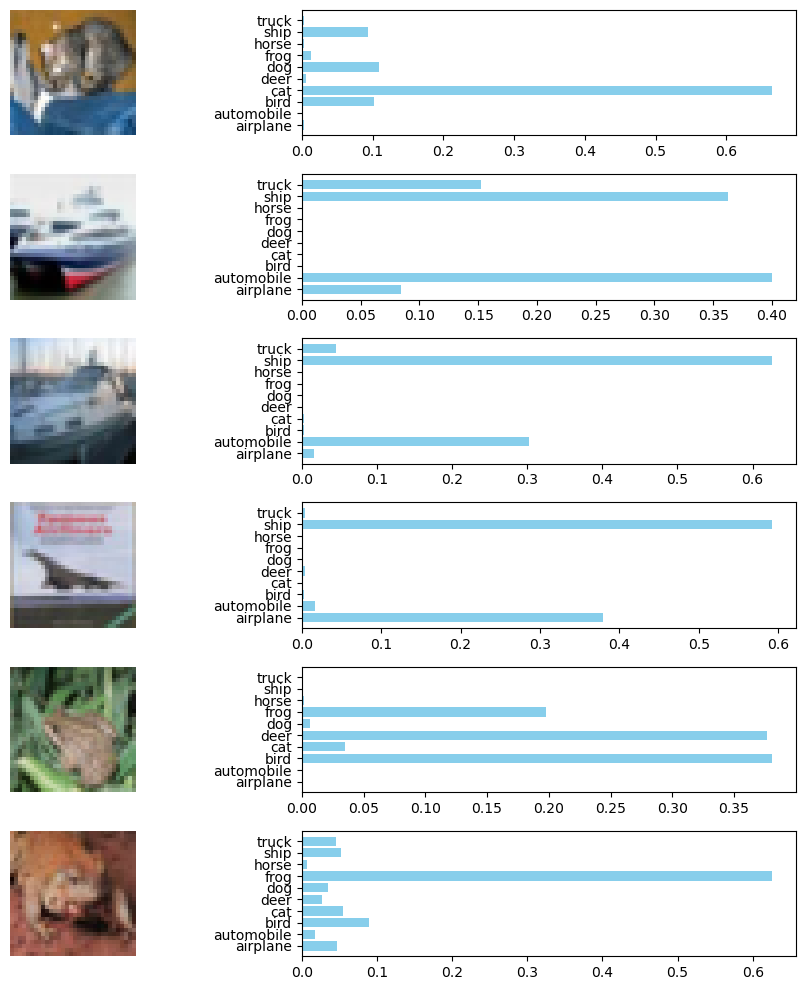

In [34]:
# Plot an image and the corresponding output probabilities of a given model.

plot_proba_from_model(cnn, test_dataset, range(6),device)

A confusion matrix is often used in supervised learning to understand how well (or not) each category is being classified.  Each element (i,j) in the confusion matrix represents the predicted class j for each true class i.  Consider the following 10 predictions for a 2 category model predicting male or female.

| example     | true category  | predicted category  |
|-------------|----------------|---------------------|
| 1           | male           | male                |
| 2           | female         | male                |
| 3           | female         | female              |
| 4           | male           | male                |
| 5           | male           | female              |
| 6           | male           | male                |
| 7           | female         | female              |
| 8           | male           | female              |
| 9           | female         | female              |
| 10          | female         | female              |

Based on the above data, the model is accurate 70% of the time.  The confusion matrix is

|        | predicted male | predicted female |
|--------|------|--------|
| true male   | 3    | 2      |
| true female | 1    | 4      |

The confusion matrix gives us more information than a simple accuracy measurement.

**Create the confusion matrix the CIFAR-10 dataset using the test data.  What does it tell you about the relationships between each class?**

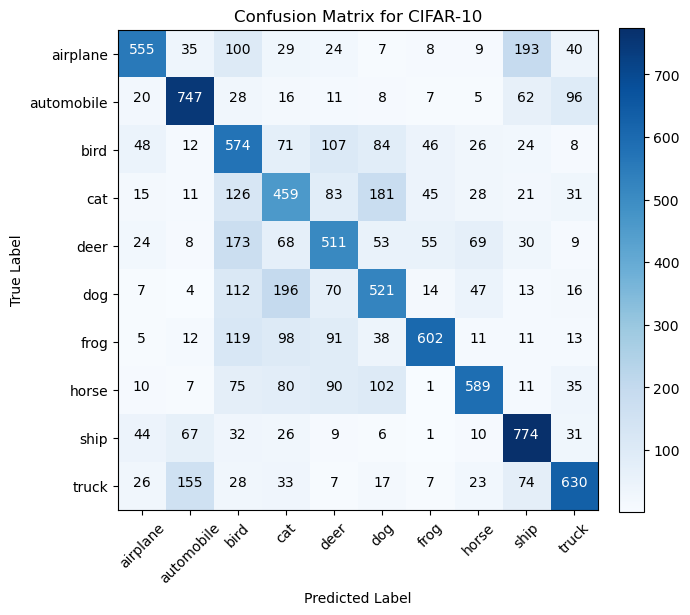

In [35]:
import sklearn.metrics as metrics

cnn.to(device)

# Set the model to evaluation mode
cnn.eval()

all_preds = []
all_labels = []

# Collect all predictions and true labels
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = cnn(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute the confusion matrix using scikit-learn (rows = true class, columns = predicted class)
cm = metrics.confusion_matrix(all_labels, all_preds)

plot_confusion_matrix(cm)

## 3.4 Try different optimizers

**You may compare the current model (trained with SGD and exponential scheduler) with the Adam optimizer (with and without scheduler)**. You may also consider other algorithms if you wish (RMSprop, Adagrad, for instance).

In [36]:
################## TODO BLOCK
# Compare optimizers on the same CNN architecture. We retrain from scratch each time and
# record the validation-accuracy history so we can plot them together below.
optimizer_histories = {}

configs = [
    ("SGD + scheduler", lambda p: torch.optim.SGD(p, lr=1e-2),  True),
    ("Adam",            lambda p: torch.optim.Adam(p, lr=1e-3), False),
    ("Adam + scheduler",lambda p: torch.optim.Adam(p, lr=1e-3), True),
]

for name, make_opt, use_scheduler in configs:
    print(f"\n===== Training with {name} =====")
    m = CnnModel()
    m.apply(init_weights)
    opt = make_opt(m.parameters())
    sched = (torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=lambda step: decay_rate ** (step / decay_steps))
             if use_scheduler else None)
    hist, _ = train_model(m, opt, sched)
    optimizer_histories[name] = hist
    # free this model before training the next optimizer (avoids memory build-up)
    import gc; del m, opt, sched; gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
################## END TODO BLOCK


===== Training with SGD + scheduler =====
Epoch 1/10  -  Train Loss: 1.7626  Train Acc: 36.28%  -  Val Loss: 1.5845  Val Acc: 42.98%
Epoch 2/10  -  Train Loss: 1.3956  Train Acc: 50.23%  -  Val Loss: 1.3677  Val Acc: 52.00%
Epoch 3/10  -  Train Loss: 1.2286  Train Acc: 56.83%  -  Val Loss: 1.2360  Val Acc: 56.78%
Epoch 4/10  -  Train Loss: 1.1095  Train Acc: 61.26%  -  Val Loss: 1.1191  Val Acc: 60.50%
Epoch 5/10  -  Train Loss: 1.0136  Train Acc: 64.66%  -  Val Loss: 1.1259  Val Acc: 61.43%
Epoch 6/10  -  Train Loss: 0.9363  Train Acc: 67.39%  -  Val Loss: 1.0820  Val Acc: 62.22%
Epoch 7/10  -  Train Loss: 0.8656  Train Acc: 69.83%  -  Val Loss: 1.0062  Val Acc: 64.36%
Epoch 8/10  -  Train Loss: 0.7981  Train Acc: 72.31%  -  Val Loss: 1.0983  Val Acc: 61.88%
Epoch 9/10  -  Train Loss: 0.7404  Train Acc: 74.19%  -  Val Loss: 0.9797  Val Acc: 66.79%
Epoch 10/10  -  Train Loss: 0.6772  Train Acc: 76.65%  -  Val Loss: 1.0198  Val Acc: 66.04%
Best Validation Accuracy: 66.79%

===== Traini

**Plot the evolution of (train/val) accuracy through epochs**

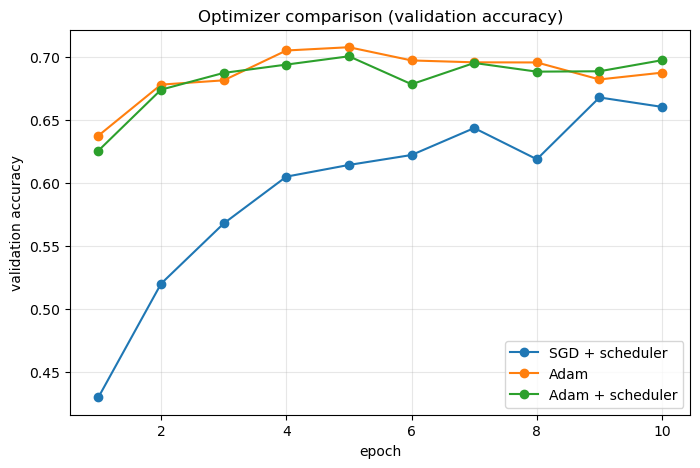

In [37]:
################## TODO BLOCK
plt.figure(figsize=(8,5))
for name, hist in optimizer_histories.items():
    plt.plot(range(1, len(hist['val_acc'])+1), hist['val_acc'], 'o-', label=name)
plt.xlabel('epoch'); plt.ylabel('validation accuracy')
plt.legend(); plt.title('Optimizer comparison (validation accuracy)'); plt.grid(True, alpha=0.3); plt.show()
################## END TODO BLOCK

<a id='pretrained_cnn'></a>
# 4 - Pretrained Networks

Several pre-trained networks are directly accessible via keras.

**Build a classifier with a better accuracy on the test set than all CNN you have built before. One rule only: do not use CNN pretrained on CIFAR10. You will:**


*   Download a model from `torchvision.models`.
*   Print its summary, understand its architecture.
*   If any, identify the layer(s) which play the role of a classifier, as opposed to the layers used for feature extraction.
*   Modify the model so that it ouputs the correct number of classes.
*   If the model has a large number of trainable parameters, you may consider freezing the feacture extraction layers (= make them non-trainable), only optimizing the last dense layers.
*   Train the model



In [38]:
# Define the model and inspect its summary

################## TODO BLOCK
from torchvision import models

# We use ResNet-18 pre-trained on ImageNet (NOT on CIFAR-10, as required by the rules).
weights = models.ResNet18_Weights.IMAGENET1K_V1
resnet = models.resnet18(weights=weights)
print(resnet)
# Architecture: a stack of convolutional "feature extraction" blocks (conv1, layer1..layer4)
# followed by an average pooling and a single fully-connected layer `fc` (1000 ImageNet classes).
# -> the convolutional layers are the FEATURE EXTRACTOR; `fc` is the CLASSIFIER head.
################## END TODO BLOCK

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [39]:
# Modify the model to output 10 classes for CIFAR-10.

################## TODO BLOCK
class PretrainedModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        # Freeze the feature-extraction layers: they keep their ImageNet-learned weights and
        # are NOT updated during training (far fewer trainable params -> fast, less overfitting).
        for p in self.backbone.parameters():
            p.requires_grad = False

        # Replace the 1000-class ImageNet head with a fresh 10-class head (this IS trainable).
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        # CIFAR images are 32x32; ResNet expects ~224x224 ImageNet-scale inputs, so we upsample.
        x = F.interpolate(x, size=224, mode='bilinear', align_corners=False)
        return self.backbone(x)

pretrained = PretrainedModel()
n_train = sum(p.numel() for p in pretrained.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in pretrained.parameters())
print(f"Trainable params: {n_train:,} / {n_total:,} total (only the new classifier head is trained)")

# Train only the new head. A few epochs suffice because the features are already strong.
# NOTE: upsampling to 224x224 makes each epoch noticeably heavier; 3 epochs is a good trade-off.
optimizer = torch.optim.Adam(pretrained.backbone.fc.parameters(), lr=1e-3)
history_pre, best_weights_pre = train_model(pretrained, optimizer, epochs=3)
################## END TODO BLOCK

Trainable params: 5,130 / 11,181,642 total (only the new classifier head is trained)
Epoch 1/3  -  Train Loss: 0.8020  Train Acc: 73.15%  -  Val Loss: 0.6157  Val Acc: 79.10%
Epoch 2/3  -  Train Loss: 0.6411  Train Acc: 78.09%  -  Val Loss: 0.5847  Val Acc: 79.83%
Epoch 3/3  -  Train Loss: 0.6195  Train Acc: 78.69%  -  Val Loss: 0.5909  Val Acc: 79.79%
Best Validation Accuracy: 79.83%


**Plot several images with their predictions. Any comment?**

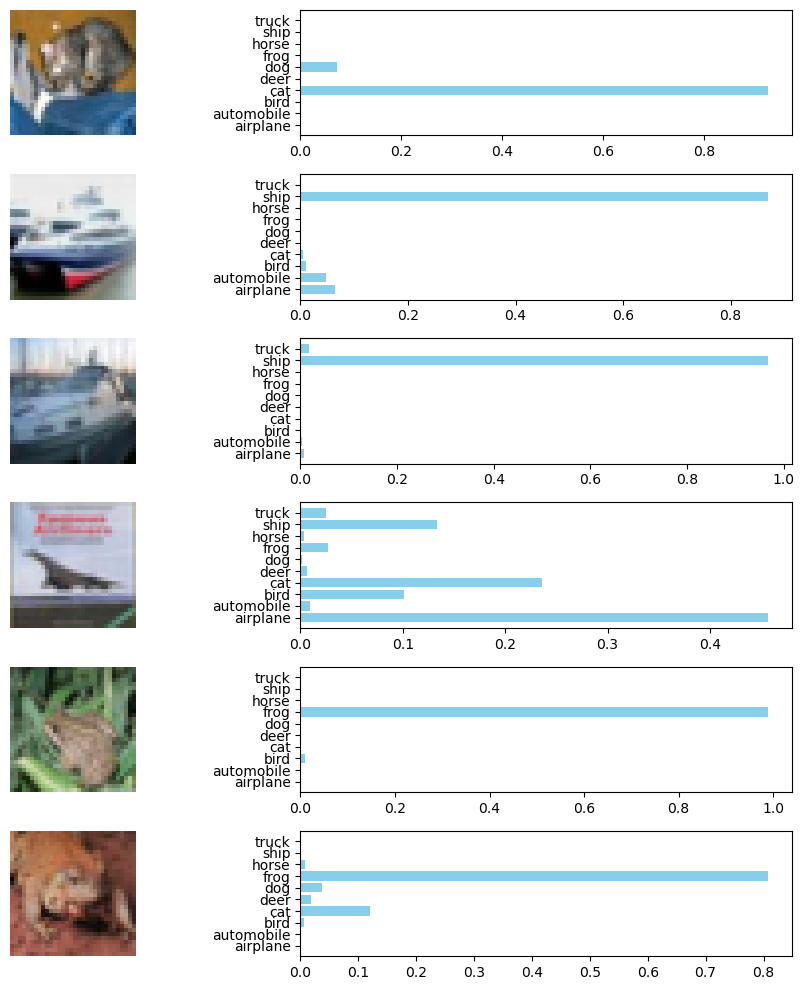

In [40]:
################## TODO BLOCK
# Load the best head weights and visualize predictions with the course helper.
pretrained.load_state_dict(best_weights_pre)
pretrained.eval()
plot_proba_from_model(pretrained, test_dataset, range(6), device)
################## END TODO BLOCK